(25346, 28)
           player  tournament id Player_initial_last  player id  DK_Hole_FP  \
0  Aaron Baddeley           2232         A. Baddeley         16        70.0   
1  Aaron Baddeley           2233         A. Baddeley         16        67.0   
2  Aaron Baddeley           2234         A. Baddeley         16        27.0   
3  Aaron Baddeley           2236         A. Baddeley         16        27.0   
4  Aaron Baddeley           2240         A. Baddeley         16        23.5   

   DK_Streak_Bonus_FP  FD_Hole_FP  FD_Streak_Bonus_FP  \
0                   6        66.2                21.1   
1                   0        64.1                20.8   
2                   0        20.9                10.6   
3                   0        18.5                 5.6   
4                   0        14.5                10.0   

                 tournament name  season  ...        date  Finish  Score  \
0  Waste Management Phoenix Open    2015  ...  2015-02-01     T17     -8   
1       AT&T Pebbl

/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_3545/2423633344.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include="object").columns


Best number of clusters: 7
            player  Cluster
0   Aaron Baddeley        0
1   Aaron Baddeley        0
2   Aaron Baddeley        0
3   Aaron Baddeley        0
4   Aaron Baddeley        0
5   Aaron Baddeley        0
6   Aaron Baddeley        0
7   Aaron Baddeley        0
8   Aaron Baddeley        0
9   Aaron Baddeley        0
10  Aaron Baddeley        0
11  Aaron Baddeley        0
12  Aaron Baddeley        0
13  Aaron Baddeley        0
14  Aaron Baddeley        0
15  Aaron Baddeley        0
16  Aaron Baddeley        0
17  Aaron Baddeley        0
18  Aaron Baddeley        0
19  Aaron Baddeley        0
Cluster
0    23437
1      284
2      251
3      391
4      234
5      601
6      148
Name: count, dtype: int64


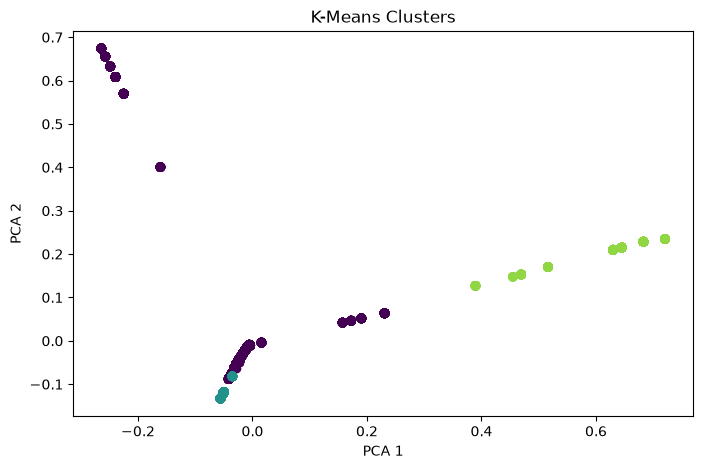

Done! Saved as PGA_KMeans_Clusters.csv


In [1]:
# 1. Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# 2. Load dataset
df = pd.read_csv("ASA All PGA Raw Data - Tourn Level.csv")

# 3. View dataset
print(df.shape)
print(df.head())
print(df.info())

# 4. Find text columns
text_cols = df.select_dtypes(include="object").columns
print("Text columns:", list(text_cols))

# Use the first text column
text_col = text_cols[0]
df[text_col] = df[text_col].fillna("").astype(str)

# 5. NLP - TF-IDF
tfidf = TfidfVectorizer(stop_words="english", max_features=1000)
X = tfidf.fit_transform(df[text_col])

# 6. Find best K using Silhouette Score
scores = {}
for k in range(2, 8):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X)
    scores[k] = silhouette_score(X, labels)

best_k = max(scores, key=scores.get)
print("Best number of clusters:", best_k)

# 7. K-Means clustering
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X)

# 8. Show cluster results
print(df[[text_col, "Cluster"]].head(20))

# 9. Cluster sizes
print(df["Cluster"].value_counts().sort_index())

# 10. Visualise clusters
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X.toarray())

plt.figure(figsize=(8,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df["Cluster"])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means Clusters")
plt.show()

# 11. Save results
df.to_csv("PGA_KMeans_Clusters.csv", index=False)

print("Done! Saved as PGA_KMeans_Clusters.csv")